In [ ]:
# " Bookstore inventory and Analytics system"

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
# Sample inventory dataset
inventory_data = {
    'Title': ['The Great Gatsby', 'To Kill a Mockingbird', '1984', 'Pride and Prejudice', 'The Hobbit', 'Sapiens'],
    'Author': ['F. Scott Fitzgerald', 'Harper Lee', 'George Orwell', 'Jane Austen', 'J.R.R. Tolkien', 'Yuval Noah Harari'],
    'Genre': ['Fiction', 'Fiction', 'Dystopian', 'Romance', 'Fantasy', 'History'],
    'Price': [12.99, 10.50, 15.00, 9.99, 14.25, 18.50],
    'Quantity': [50, 35, 40, 20, 30, 25]
}

# Sample sales dataset
sales_data = {
    'Date': [
        '2026-01-05', '2026-01-15', '2026-02-02', '2026-02-20', 
        '2026-03-10', '2026-03-25', '2026-04-05', '2026-04-18',
        '2026-05-12', '2026-05-30', '2026-06-14', '2026-06-28'
    ],
    'Title': [
        '1984', 'The Great Gatsby', 'The Hobbit', '1984', 
        'Sapiens', 'To Kill a Mockingbird', 'Pride and Prejudice', 'The Great Gatsby',
        '1984', 'Sapiens', 'The Hobbit', 'Pride and Prejudice'
    ],
    'Quantity Sold': [5, 3, 4, 6, 2, 5, 4, 7, 8, 3, 5, 2],
    'Total Revenue': [75.0, 38.97, 57.0, 90.0, 37.0, 52.5, 39.96, 90.93, 120.0, 55.5, 71.25, 19.98]
}

# Save generated data to CSV files
pd.DataFrame(inventory_data).to_csv('inventory.csv', index=False)
pd.DataFrame(sales_data).to_csv('sales.csv', index=False)
print("Files 'inventory.csv' and 'sales.csv' generated successfully.")

Files 'inventory.csv' and 'sales.csv' generated successfully.


In [10]:
inv_df = pd.read_csv('inventory.csv')
sales_df = pd.read_csv('sales.csv')

print("--- Inventory CSV Preview ---")
display(inv_df.head(3))

print("\n--- Sales CSV Preview ---")
display(sales_df.head(3))

--- Inventory CSV Preview ---


,Title,Author,Genre,Price,Quantity
0,The Great Gatsby,F. Scott Fitzgerald,Fiction,12.99,50
1,To Kill a Mockingbird,Harper Lee,Fiction,10.50,35
2,1984,George Orwell,Dystopian,15.00,40



--- Sales CSV Preview ---


,Date,Title,Quantity Sold,Total Revenue
0,2026-01-05,1984,5,75.00
1,2026-01-15,The Great Gatsby,3,38.97
2,2026-02-02,The Hobbit,4,57.00


In [11]:
class Bookstore:
    def __init__(self, inventory_file='inventory.csv', sales_file='sales.csv'):
        self.inventory_file = inventory_file
        self.sales_file = sales_file
        self.load_data()

    def load_data(self):
        self.inventory_df = pd.read_csv(self.inventory_file)
        self.sales_df = pd.read_csv(self.sales_file)

    def save_data(self):
        self.inventory_df.to_csv(self.inventory_file, index=False)
        self.sales_df.to_csv(self.sales_file, index=False)

    def add_book(self, title, author, genre, price, quantity):
        if price <= 0:
            print("Validation Error: Price must be positive.")
            return
        if quantity <= 0 or not isinstance(quantity, int):
            print("Validation Error: Quantity must be a positive integer.")
            return

        if title in self.inventory_df['Title'].values:
            print(f"Book '{title}' already exists. Use update_inventory().")
        else:
            new_book = pd.DataFrame([{
                'Title': title, 
                'Author': author, 
                'Genre': genre, 
                'Price': float(price), 
                'Quantity': int(quantity)
            }])
            self.inventory_df = pd.concat([self.inventory_df, new_book], ignore_index=True)
            self.save_data()
            print(f"Added '{title}' to inventory.")

    def update_inventory(self, title, quantity):
        if title not in self.inventory_df['Title'].values:
            print(f"Error: '{title}' not found.")
            return

        idx = self.inventory_df[self.inventory_df['Title'] == title].index[0]
        new_quantity = self.inventory_df.at[idx, 'Quantity'] + quantity

        if new_quantity < 0:
            print("Error: Quantity cannot fall below zero.")
            return

        self.inventory_df.at[idx, 'Quantity'] = new_quantity
        self.save_data()
        print(f"Updated '{title}' quantity to {new_quantity}.")

    def record_sale(self, title, quantity, date=None):
        if title not in self.inventory_df['Title'].values:
            print(f"Error: '{title}' not found in inventory.")
            return

        if date is None:
            date = datetime.now().strftime('%Y-%m-%d')

        idx = self.inventory_df[self.inventory_df['Title'] == title].index[0]
        available_qty = self.inventory_df.at[idx, 'Quantity']
        unit_price = self.inventory_df.at[idx, 'Price']

        if quantity <= 0 or quantity > available_qty:
            print(f"Error: Invalid quantity. Available stock: {available_qty}.")
            return

        self.inventory_df.at[idx, 'Quantity'] -= quantity
        total_rev = unit_price * quantity
        new_sale = pd.DataFrame([{
            'Date': date,
            'Title': title,
            'Quantity Sold': quantity,
            'Total Revenue': total_rev
        }])
        self.sales_df = pd.concat([self.sales_df, new_sale], ignore_index=True)
        self.save_data()
        print(f"Recorded sale of {quantity} x '{title}' for ${total_rev:.2f}.")

    def generate_report(self):
        print("\n" + "="*40)
        print("     BOOKSTORE INVENTORY & SALES REPORT     ")
        print("="*40)
        print(f"Total Unique Titles : {len(self.inventory_df)}")
        print(f"Total Stock Volume  : {self.inventory_df['Quantity'].sum()}")
        print(f"Total Revenue       : ${self.sales_df['Total Revenue'].sum():.2f}")
        print("="*40 + "\n")

In [12]:
store = Bookstore()
print("Bookstore object initialized successfully.")

Bookstore object initialized successfully.


In [13]:
# Add new book
store.add_book("Dune", "Frank Herbert", "Sci-Fi", 16.50, 40)

# Update existing inventory quantity
store.update_inventory("1984", 10)

Added 'Dune' to inventory.
Updated '1984' quantity to 50.


In [14]:
# Record a sales transaction
store.record_sale("Dune", 5, "2026-07-01")

Recorded sale of 5 x 'Dune' for $82.50.


In [15]:
store.generate_report()


     BOOKSTORE INVENTORY & SALES REPORT     
Total Unique Titles : 7
Total Stock Volume  : 245
Total Revenue       : $830.59



In [17]:
# Load fresh CSV data for analysis
inv_df = pd.read_csv('inventory.csv')
sales_df = pd.read_csv('sales.csv')

In [18]:
prices_array = np.array(inv_df['Price'])
revenues_array = np.array(sales_df['Total Revenue'])

# NumPy metrics
total_revenue = np.sum(revenues_array)
avg_price = np.mean(prices_array)

# Calculate monthly revenue growth rate using NumPy
sales_df['Date'] = pd.to_datetime(sales_df['Date'])
sales_df['Month'] = sales_df['Date'].dt.to_period('M')
monthly_rev = sales_df.groupby('Month')['Total Revenue'].sum().to_numpy()

growth_rates = np.diff(monthly_rev) / monthly_rev[:-1] * 100

print(f"Total Revenue (NumPy): ${total_revenue:.2f}")
print(f"Average Book Price (NumPy): ${avg_price:.2f}")
print(f"Monthly Growth Rates (%): {np.round(growth_rates, 2)}")

Total Revenue (NumPy): $830.59
Average Book Price (NumPy): $13.96
Monthly Growth Rates (%): [ 28.98 -39.12  46.25  34.08 -48.02  -9.57]


In [19]:
# Merge sales and inventory datasets
merged_df = sales_df.merge(inv_df, on='Title', how='left')

# Grouping and aggregations
sales_by_genre = merged_df.groupby('Genre')['Total Revenue'].sum().reset_index()
sales_by_author = merged_df.groupby('Author')['Total Revenue'].sum().reset_index()
best_sellers = merged_df.groupby('Title')['Quantity Sold'].sum().sort_values(ascending=False).reset_index()

print("--- Best Selling Books ---")
display(best_sellers)

--- Best Selling Books ---


,Title,Quantity Sold
0,1984,19
1,The Great Gatsby,10
2,The Hobbit,9
3,Pride and Prejudice,6
4,Dune,5
5,Sapiens,5
6,To Kill a Mockingbird,5


C:\Users\admin\AppData\Local\Temp\ipykernel_7036\2833214996.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_by_genre, x='Genre', y='Total Revenue', palette='viridis')


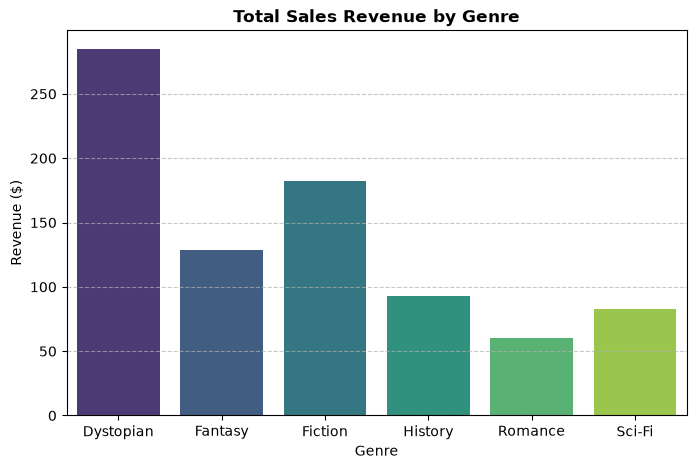

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(data=sales_by_genre, x='Genre', y='Total Revenue', palette='viridis')
plt.title('Total Sales Revenue by Genre', fontsize=12, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Revenue ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

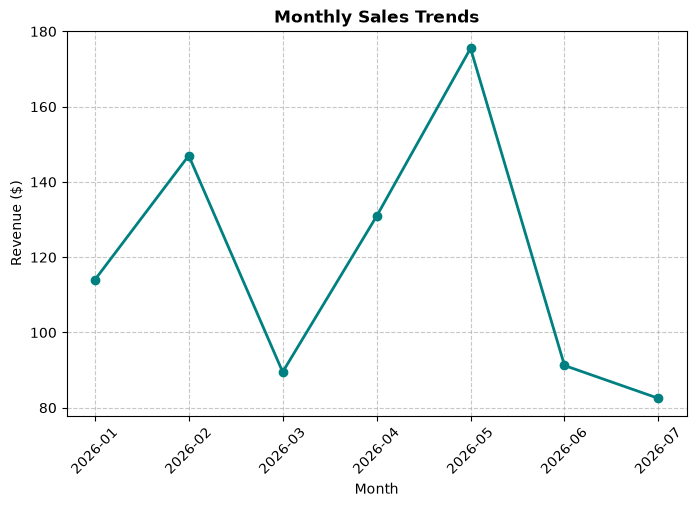

In [21]:
monthly_trends = sales_df.groupby(sales_df['Date'].dt.strftime('%Y-%m'))['Total Revenue'].sum().reset_index()

plt.figure(figsize=(8, 5))
plt.plot(monthly_trends['Date'], monthly_trends['Total Revenue'], marker='o', color='teal', linewidth=2)
plt.title('Monthly Sales Trends', fontsize=12, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

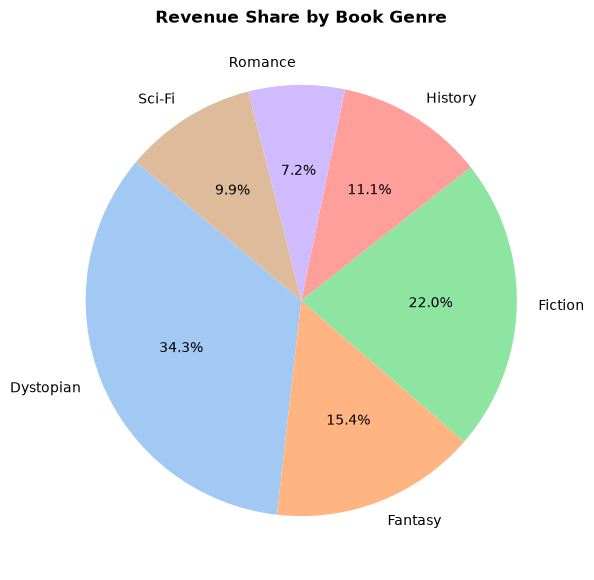

In [22]:
plt.figure(figsize=(7, 7))
plt.pie(
    sales_by_genre['Total Revenue'], 
    labels=sales_by_genre['Genre'], 
    autopct='%1.1f%%', 
    colors=sns.color_palette('pastel'),
    startangle=140
)
plt.title('Revenue Share by Book Genre', fontsize=12, fontweight='bold')
plt.show()

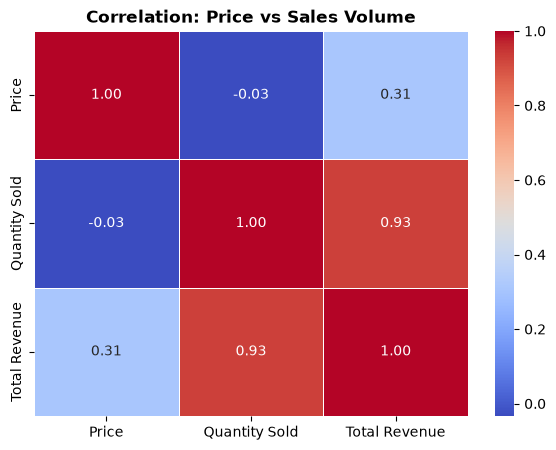

In [23]:
plt.figure(figsize=(7, 5))
corr_data = merged_df[['Price', 'Quantity Sold', 'Total Revenue']].corr()
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation: Price vs Sales Volume', fontsize=12, fontweight='bold')
plt.show()